In [93]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import datetime
from datetime import datetime



PV_CSV_PATH = "pv_data.csv"
WEATHER_CSV_PATH = "weather_data.csv"

TARGET_COL = "pv"

ALL_FEATURES = [
    "soc","load","pv","sun_hours","temperature","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

PAST_FEATURES = ALL_FEATURES.copy()

EXOG_FEATURES = [
    "temperature","sun_hours","glob_radiation_wm2",
    "hour_sin","hour_cos","dow_sin","dow_cos","woy_sin","woy_cos"
]

# Time-series lags (hours)
LAGS = [1, 2, 3, 4, 5, 6, 12]

def load_and_merge():
    # --- Load PV data (5-min → hourly) ---
    pv_df = pd.read_csv(
        PV_CSV_PATH, sep=",",
        parse_dates=["timestamp"],
        index_col="timestamp"
    )
    pv_df = pv_df.apply(pd.to_numeric, errors="coerce")
    pv_hourly = pv_df.resample("1h").mean()

    # --- Load weather data ---
    weather_df = pd.read_csv(
        WEATHER_CSV_PATH,
        sep=",",
        parse_dates=["time"],
        index_col="time"
    )
    if weather_df.index.tz is not None:
        weather_df.index = weather_df.index.tz_convert(None)
    weather_df = weather_df.apply(pd.to_numeric, errors="coerce")

        # date range fix
    #weather_df = weather_df.loc["2024-07-01":"2025-10-20"]

    # --- Merge PV + weather ---
    df = pv_hourly.join(weather_df, how="inner")

    df['DATE'] = df.index
    df['DATE'] = pd.to_datetime(df['DATE']).dt.date

    return df

In [94]:
df = load_and_merge()

In [92]:
df[['soc', 'pv', 'load', 'temperature', 'glob_radiation_wm2']].describe().round(2)

,soc,pv,load,temperature,glob_radiation_wm2
count,11489.00,11489.00,11489.00,11545.00,11569.00
mean,35.78,9.93,0.96,13.33,149.87
std,39.56,24.19,1.40,8.95,228.90
min,0.00,0.00,-0.58,-9.60,0.00
25%,1.00,0.00,0.06,6.00,0.00
50%,6.00,0.61,0.44,13.30,9.00
75%,74.33,4.20,1.08,19.90,233.00
max,100.00,100.00,6.50,36.10,902.00


In [72]:
df.shape
#df['DATE'].max()

(11569, 13)

In [95]:
groupby = df.groupby(['DATE']) #.aggregate(['soc', 'pv', 'load', 'temperature', 'glob_radiation_wm2'])

df = pd.DataFrame({
    'soc': groupby['soc'].mean(),
    'pv': groupby['pv'].mean(),
    'load': groupby['load'].mean(),
    'temperature': groupby['temperature'].mean(),
    'glob_radiation_wm2': groupby['glob_radiation_wm2'].mean()
})

scaler_all = StandardScaler()

scaler_all.fit(df[['soc', 'pv', 'load', 'temperature', 'glob_radiation_wm2']])

df[['soc', 'pv', 'load', 'temperature', 'glob_radiation_wm2']] = scaler_all.transform(df[['soc', 'pv', 'load', 'temperature', 'glob_radiation_wm2']])

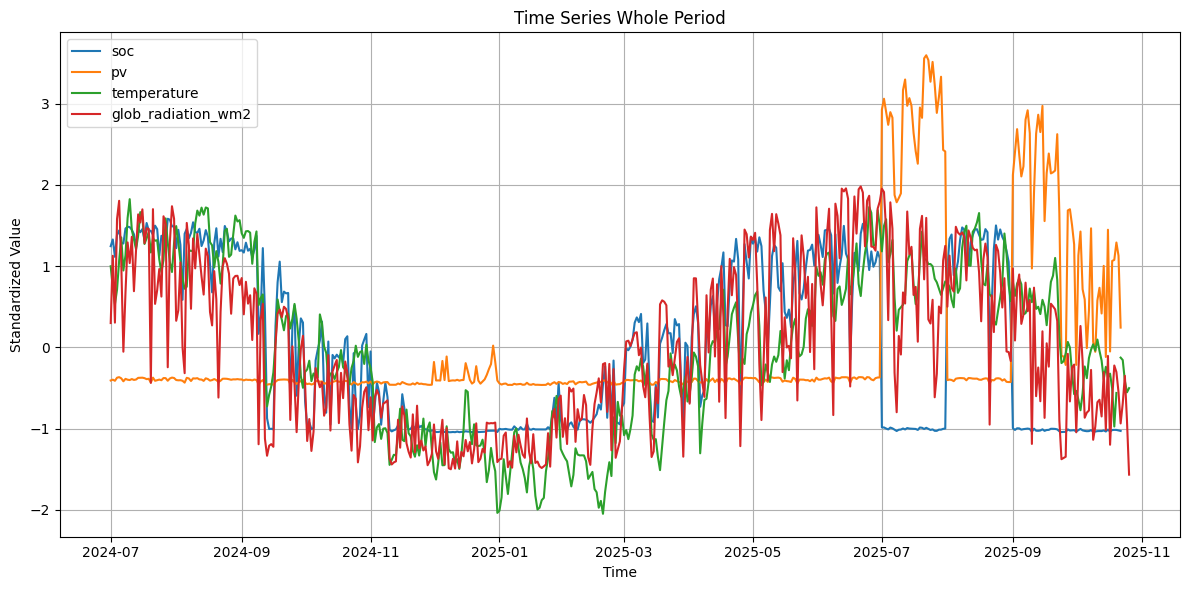

In [97]:
cols_to_plot = ["soc","pv", "temperature", "glob_radiation_wm2"]  # adjust names to your actual columns

# Plot
plt.figure(figsize=(12, 6))
for col in cols_to_plot:
    if col in df.columns:
        plt.plot(df.index, df[col], label=col)

plt.title("Time Series Whole Period")
plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()